# 🛰️ Satellite Communication Intrusion Detection - Analytics & Visualisation

This notebook provides a comprehensive analysis of the simulated satellite communication data and evaluates the performance of various machine learning models for intrusion detection.

### 🎯 Objectives:
1. **Exploratory Data Analysis (EDA)**: Understand the characteristics of different attack vectors.
2. **Feature Distribution**: Visualize how features like signal strength and frequency shift under attack.
3. **Model Evaluation**: Compare accuracy, precision, and latency across different algorithms.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ensure project root is in path for imports
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from app.ml.simulator import generate

# Global Styling
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

print("✅ Setup complete. Libraries imported and path configured.")

✅ Setup complete. Libraries imported and path configured.


## 📊 Data Generation
We use the `simulator` module to generate a balanced dataset of normal and malicious satellite communication packets.

In [2]:
# Generate synthetic satellite telemetry data
df = generate(n_samples=5000, attack_ratio=0.4)
print(f"📦 Dataset generated: {df.shape[0]} samples, {df.shape[1]} features.")

# Display class distribution
print("\nTraffic Distribution:")
print(df['label'].value_counts())

df.head()

📦 Dataset generated: 5000 samples, 9 features.

Traffic Distribution:
label
normal      3000
jamming      500
spoofing     500
dos          500
replay       500
Name: count, dtype: int64


,src_ip,dst_ip,protocol,payload_size,frequency,signal_strength,inter_arrival_time,label,timestamp
0,192.168.1.66,10.0.0.5,TCP,595.698725,106.499892,-59.790932,0.058217,normal,2026-04-27 11:08:10.460326+00:00
1,192.168.1.94,10.0.0.3,UDP,489.649527,95.151712,-55.360058,0.011302,normal,2026-04-27 11:08:10.460326+00:00
2,192.168.1.95,10.0.0.5,TCP,561.869229,102.600561,-57.676840,0.165387,normal,2026-04-27 11:08:10.460326+00:00
3,192.168.1.252,10.0.0.4,TCP,468.482649,97.452379,-62.589832,0.014503,normal,2026-04-27 11:08:10.460326+00:00
4,192.168.1.143,10.0.0.5,TCP,592.309958,99.205836,-60.446204,0.114136,normal,2026-04-27 11:08:10.460326+00:00


## 🔍 Exploratory Data Analysis

### 1. Traffic Class Distribution
Visualizing the proportions of different attack types compared to normal traffic.

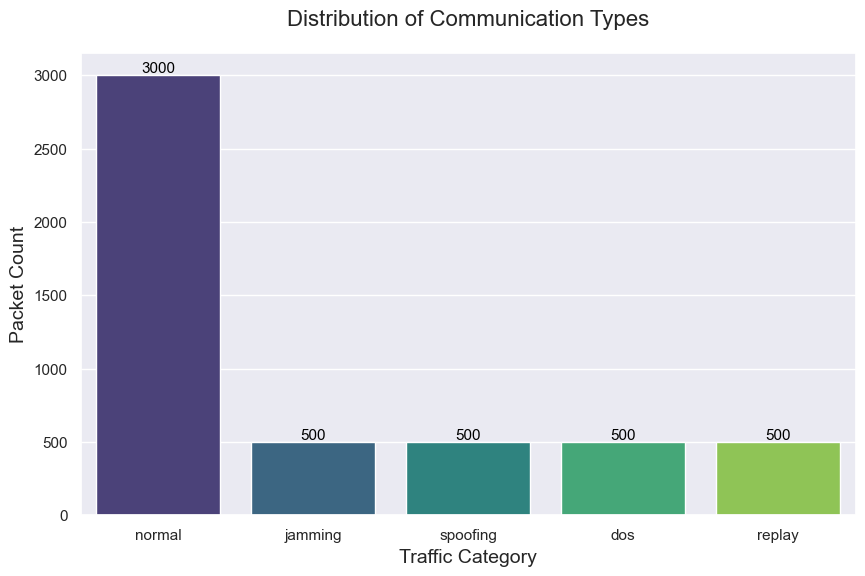

In [3]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Communication Types', pad=20)
plt.xlabel('Traffic Category')
plt.ylabel('Packet Count')

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

### 2. Feature Distributions per Class
Understanding how specific metrics like `Signal Strength` and `Frequency` deviate during different types of intrusions.

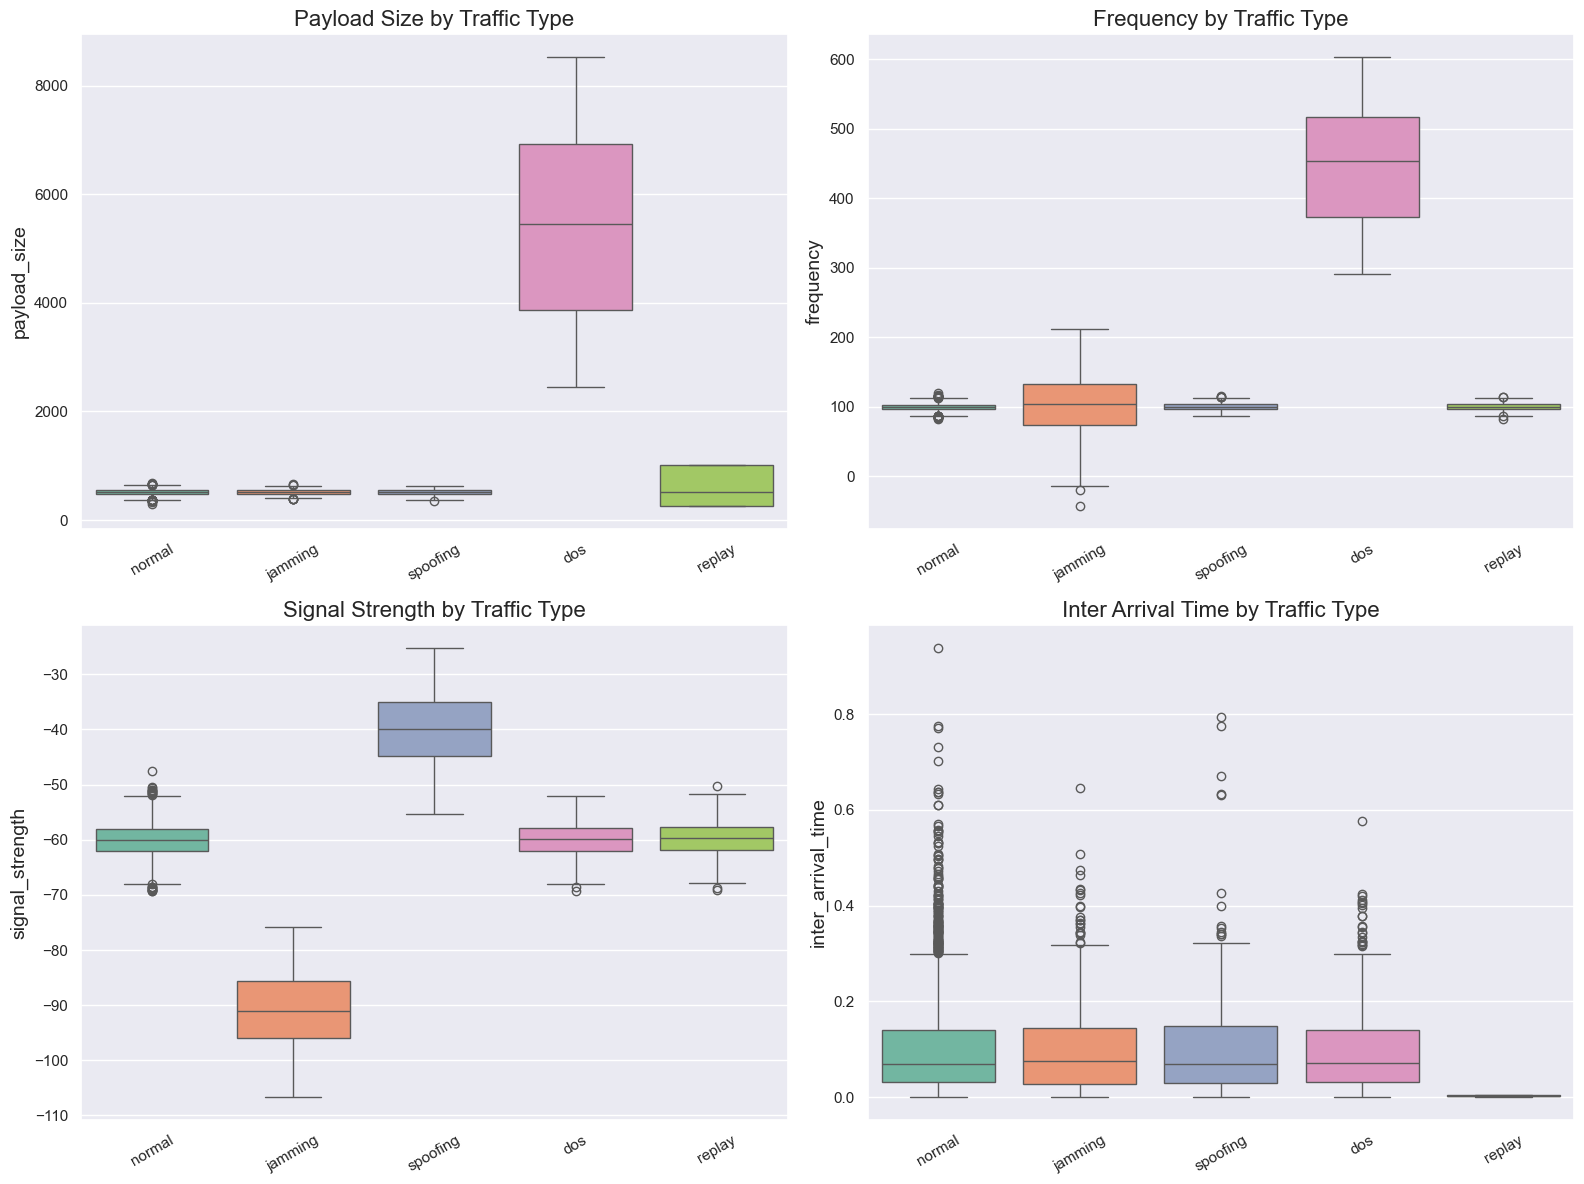

In [4]:
features = ['payload_size', 'frequency', 'signal_strength', 'inter_arrival_time']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i], palette='Set2', hue='label', legend=False)
    axes[i].set_title(f'{feature.replace("_", " ").title()} by Traffic Type')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 3. Feature Relationship (Cluster Analysis)
Scatter plot showing how Signal Strength and Frequency can be used to cluster different attack types.

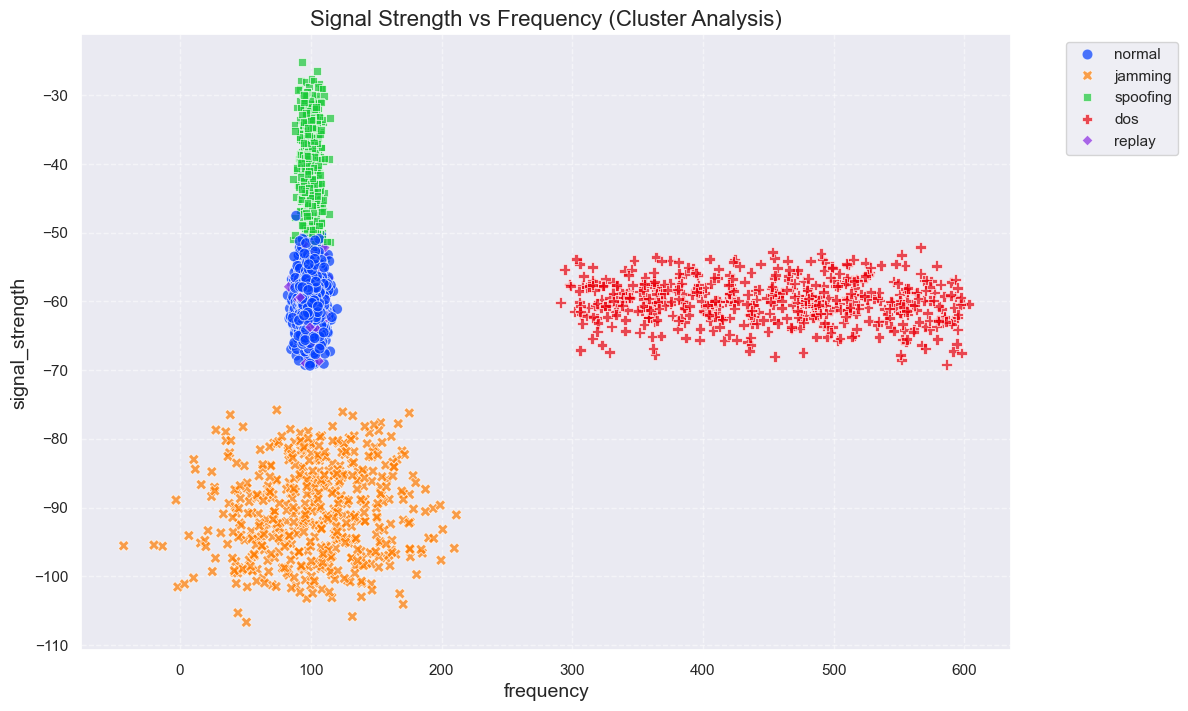

In [5]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='frequency', y='signal_strength', hue='label', style='label', alpha=0.7, palette='bright', s=60)
plt.title('Signal Strength vs Frequency (Cluster Analysis)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 4. Correlation Matrix
Checking for multi-collinearity and relationships between features.

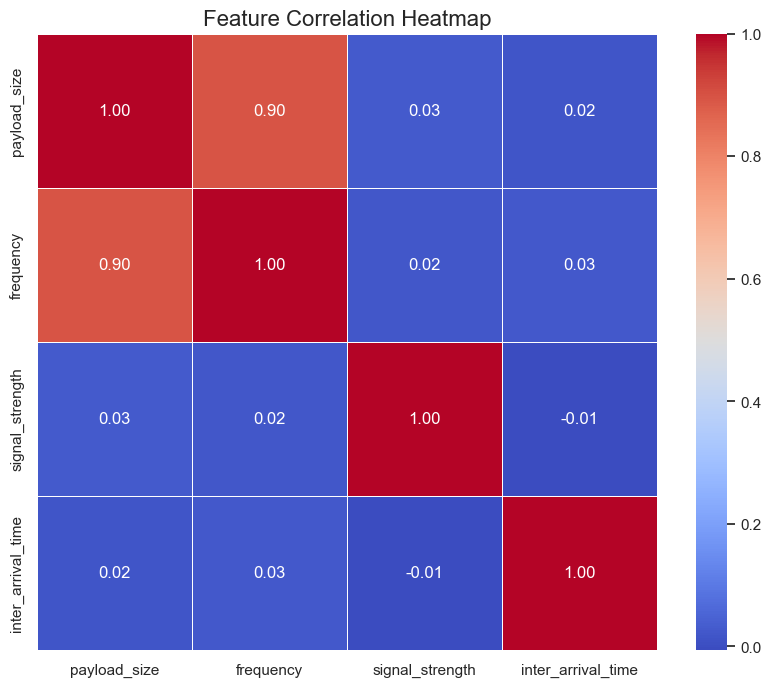

In [6]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 🏆 Model Performance Comparison

Comparison of various AI algorithms based on pre-calculated performance metrics stored in `algorithm_comparison.csv`.

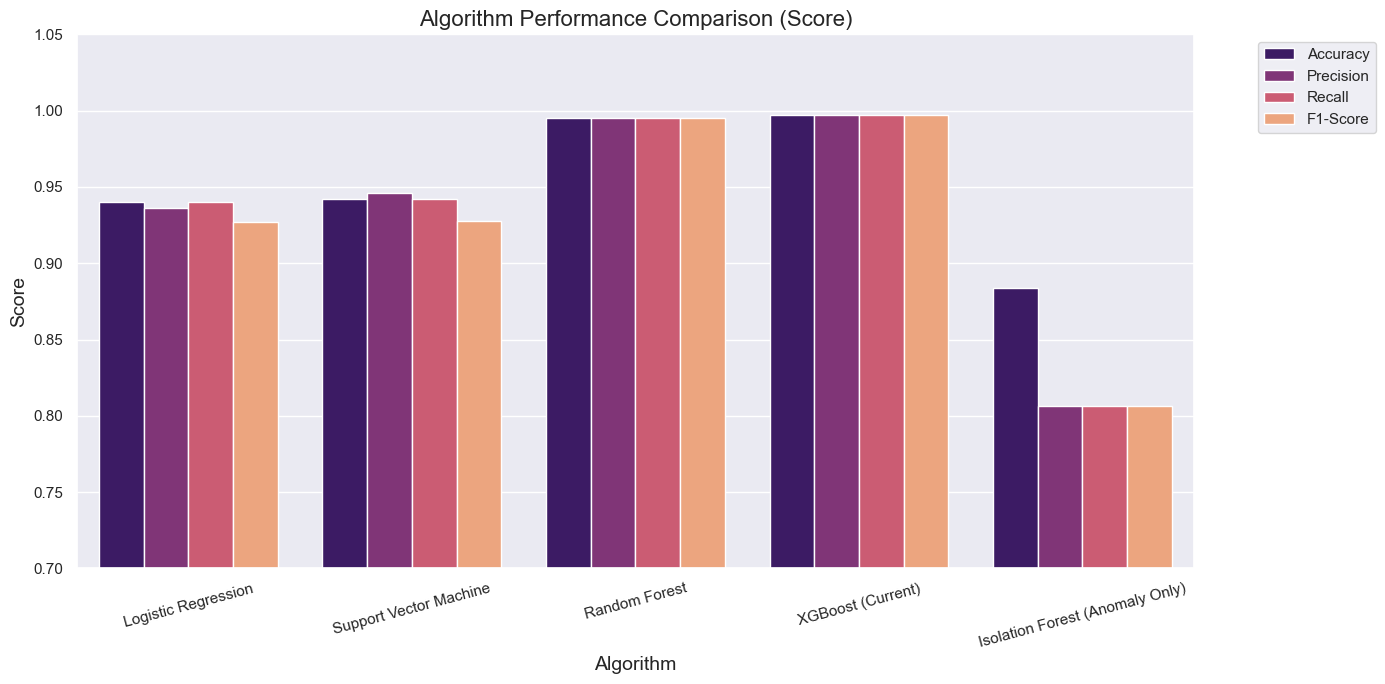

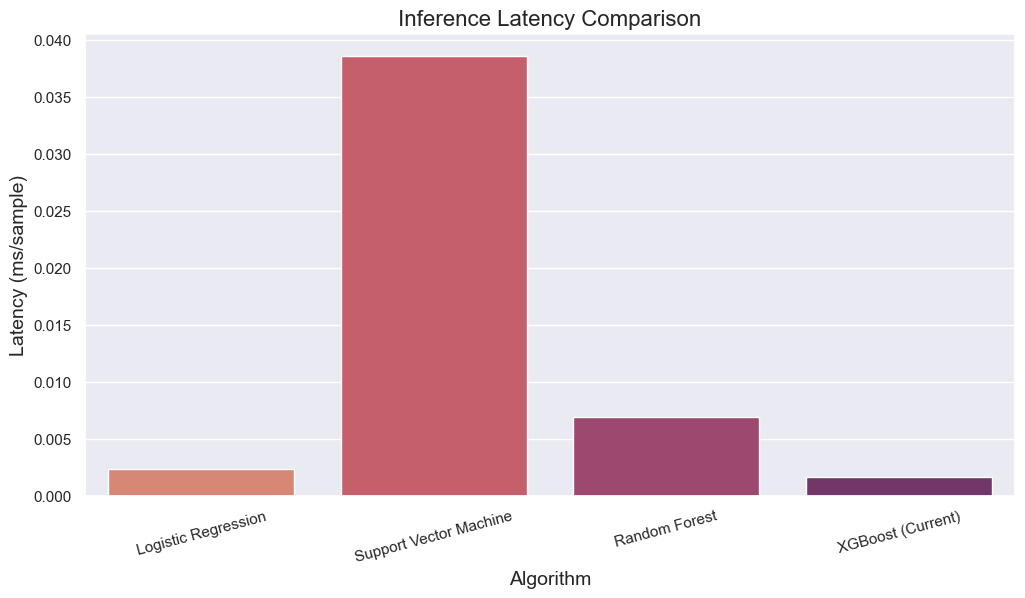

In [7]:
if os.path.exists('algorithm_comparison.csv'):
    comp_df = pd.read_csv('algorithm_comparison.csv')
    
    # Performance Metrics Comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    comp_melted = comp_df.melt(id_vars='Algorithm', value_vars=metrics, var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(14, 7))
    sns.barplot(data=comp_melted, x='Algorithm', y='Score', hue='Metric', palette='magma')
    plt.title('Algorithm Performance Comparison (Score)')
    plt.ylim(0.7, 1.05)
    plt.xticks(rotation=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Latency Comparison
    plt.figure(figsize=(12, 6))
    sns.barplot(data=comp_df.dropna(), x='Algorithm', y='Inference Time (ms/sample)', hue='Algorithm', palette='flare', legend=False)
    plt.title('Inference Latency Comparison')
    plt.ylabel('Latency (ms/sample)')
    plt.xticks(rotation=15)
    plt.show()
else:
    print("❌ algorithm_comparison.csv not found. Please run 'python comparison.py' to generate model metrics.")

## 📌 Conclusion

- **XGBoost** and **Random Forest** demonstrate superior accuracy (>99%) for satellite intrusion detection.
- **Jamming attacks** are most easily identified by significant drops in `Signal Strength` and shifts in `Frequency`.
- **DoS attacks** show massive spikes in `Payload Size` and `Frequency` rate.
- **Latency** is minimal (<0.01ms/sample) for XGBoost, making it suitable for real-time edge processing on satellite hardware.